In [2]:
pip install kagglehub


   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("samuelcortinhas/apples-or-tomatoes-image-classification")

print("Path to dataset files:", path)

100%|██████████| 2.33M/2.33M [00:00<00:00, 160MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/samuelcortinhas/apples-or-tomatoes-image-classification/versions/1


In [7]:
import os
import tensorflow as tf
DATASET_DIR = path
IMAGE_SIZE = (100,100)
BATCH_SIZE = 32
SEED = 123
LABEL_MODE_BINARY = "binary"
train_dir = os.path.join(DATASET_DIR,"train")
test_dir = os.path.join(DATASET_DIR,"test")

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    label_mode = LABEL_MODE_BINARY,
    seed = SEED,
    shuffle = True
)

Found 294 files belonging to 2 classes.


In [11]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    label_mode = LABEL_MODE_BINARY,
    seed = 123,
    shuffle = False
)

Found 97 files belonging to 2 classes.


In [12]:
print(len(train_ds))
print(len(test_ds))

10
4


In [13]:
classes = train_ds.class_names
print("class names:",classes)

class names: ['apples', 'tomatoes']


In [14]:
1

1

In [15]:
def normlization(image,lable):
    image = tf.cast(image/255. ,tf.float32)
    return image, lable

In [16]:
train_ds = train_ds.map(normlization)
test_ds = test_ds.map(normlization)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D,MaxPooling2D,Flatten

In [19]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3),padding="valid",activation="relu", input_shape = (100,100,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding="valid"))
model.add(Conv2D(64,kernel_size=(3,3),padding = "valid",activation= "relu"))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding="valid"))
model.add(Conv2D(128,kernel_size=(3,3),padding = "valid",activation= "relu"))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding="valid"))
model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dense(64,activation="relu"))
model.add(Dense(1, activation="sigmoid"))


In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,740,097 (6.64 MB)

 Trainable params: 1,740,097 (6.64 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(optimizer="adam", loss="binary_crossentropy",metrics=["accuracy"])

In [23]:
history = model.fit(train_ds,validation_data=(test_ds),epochs=30)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 428ms/step - accuracy: 0.5136 - loss: 0.7149 - val_accuracy: 0.5979 - val_loss: 0.6798
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5918 - loss: 0.6640 - val_accuracy: 0.6082 - val_loss: 0.6499
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6735 - loss: 0.6163 - val_accuracy: 0.6082 - val_loss: 0.6655
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6633 - loss: 0.6072 - val_accuracy: 0.6495 - val_loss: 0.6370
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7041 - loss: 0.5763 - val_accuracy: 0.6186 - val_loss: 0.6560
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7075 - loss: 0.5729 - val_accuracy: 0.6495 - val_loss: 0.6073
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6837 - loss: 0.5954 - val_accuracy: 0.7010 - val_loss: 0.5985
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7585 - loss: 0.5165 - val_accuracy: 0.7010 - 

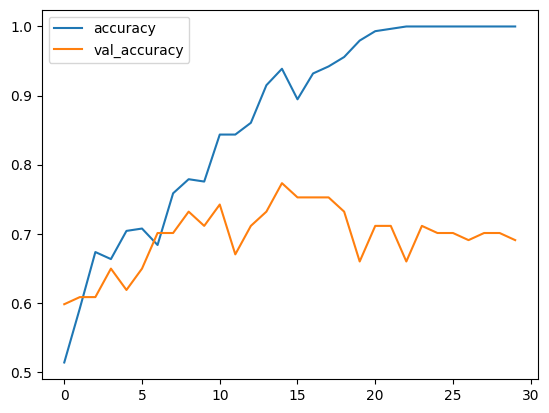

In [24]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"], label = "accuracy")
plt.plot(history.history["val_accuracy"], label = "val_accuracy")
plt.legend()
plt.show()